In [1]:
import glob
data = glob.glob('Images/*')

In [2]:
len(data)

1472

In [3]:
data[:100]

['Images/IMG-20250620-WA0375.jpg',
 'Images/IMG-20250619-WA0048.jpg',
 'Images/IMG-20250619-WA0053.txt',
 'Images/IMG-20250617-WA0106.jpg',
 'Images/IMG-20250619-WA0041.jpg',
 'Images/IMG-20250617-WA0161.jpg',
 'Images/IMG-20250620-WA0294.jpg',
 'Images/IMG-20250618-WA0109.jpg',
 'Images/IMG-20250619-WA0156.jpg',
 'Images/IMG-20250618-WA0100.xml',
 'Images/IMG-20250619-WA0043.jpg',
 'Images/IMG-20250617-WA0022.jpg',
 'Images/WhatsApp Image 2025-06-23 at 12.34.17 PM.xml',
 'Images/IMG-20250617-WA0250.jpg',
 'Images/IMG-20250617-WA0089.xml',
 'Images/IMG-20250619-WA0165.txt',
 'Images/IMG-20250619-WA0140.txt',
 'Images/IMG-20250617-WA0201.jpg',
 'Images/IMG-20250617-WA0156.jpg',
 'Images/IMG-20250618-WA0046.jpg',
 'Images/IMG-20250620-WA0355.jpg',
 'Images/IMG-20250619-WA0114.jpg',
 'Images/WhatsApp Image 2025-06-23 at 12.34.54 PM.jpeg',
 'Images/WhatsApp Image 2025-06-23 at 12.33.47 PM.jpeg',
 'Images/IMG-20250618-WA0096.jpg',
 'Images/IMG-20250620-WA0471.jpg',
 'Images/IMG-20250618-WA0

In [11]:
import os
import random
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import cv2

# Path to your image folder
img_dir = "Images"

# Collect XML files
xml_files = [f for f in os.listdir(img_dir) if f.endswith(".xml")]

# Pick 10 random annotation files
sample_xml = random.sample(xml_files, 2)

def load_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []

    for obj in root.findall('object'):
        name = obj.find('name').text
        bbox = obj.find('bndbox')
        xmin = int(bbox.find('xmin').text)
        ymin = int(bbox.find('ymin').text)
        xmax = int(bbox.find('xmax').text)
        ymax = int(bbox.find('ymax').text)

        objects.append((name, xmin, ymin, xmax, ymax))

    filename = root.find('filename').text
    return filename, objects


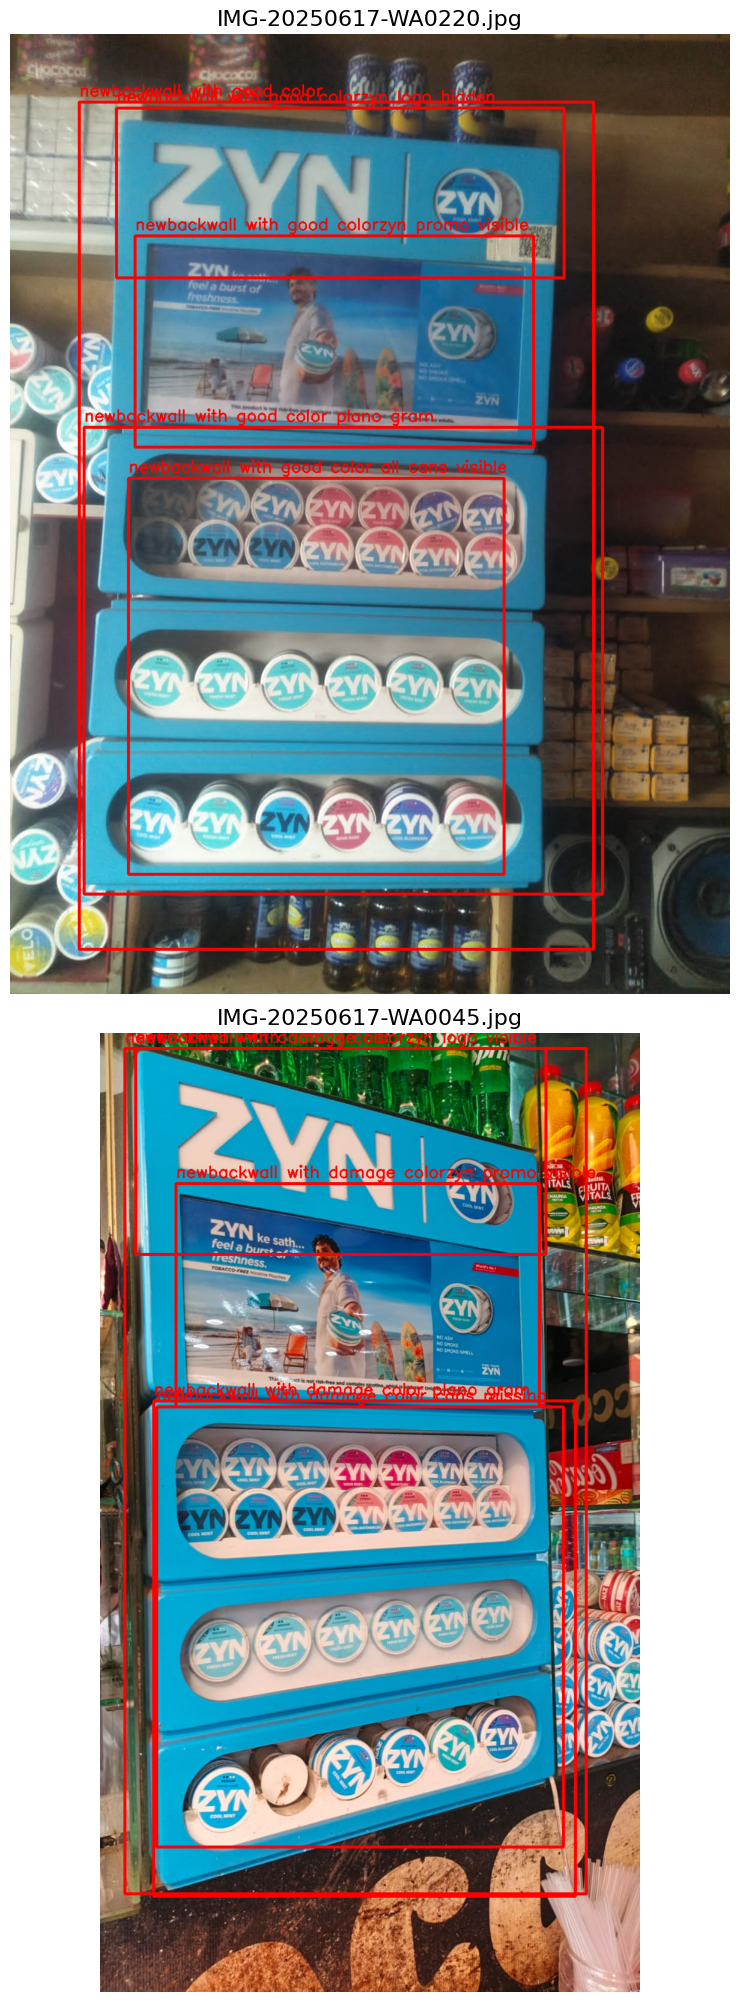

In [16]:
import os
import random
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import cv2

# Path to your image folder
img_dir = "Images"

# Collect XML files
xml_files = [f for f in os.listdir(img_dir) if f.endswith(".xml")]

# Pick 10 random annotation files
sample_xml = random.sample(xml_files, 2)

def load_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []

    for obj in root.findall("object"):
        name = obj.find("name").text
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)
        objects.append((name, xmin, ymin, xmax, ymax))

    filename = root.find("filename").text
    return filename, objects

# Show large images (one per row)
plt.figure(figsize=(15, 100))  # Very tall layout

for idx, xml_file in enumerate(sample_xml):
    xml_path = os.path.join(img_dir, xml_file)
    filename, objects = load_annotation(xml_path)

    img_path = os.path.join(img_dir, filename)
    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw bounding boxes
    for obj in objects:
        name, xmin, ymin, xmax, ymax = obj
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 3)
        cv2.putText(img, name, (xmin, ymin - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9,
                    (255, 0, 0), 2)

    plt.subplot(10, 1, idx + 1)   # 10 rows, 1 column
    plt.imshow(img)
    plt.axis("off")
    plt.title(filename, fontsize=16)

plt.tight_layout()
plt.show()